# V1.2 — Operator-splitting stability for stiff cyclic coupling

**Tier 1 / Verification Protocol §V1.2.** Targets architecture **Decision #12** — operators
compose by staging contributions into shared conserved buses — on the *flagship stiff
phenomenon*: the **char ↔ conduction ↔ pyrolysis ↔ combustion** loop. Depends on **V0.3**
(the conserved-bus runtime + the monolithic oracle).

> Folder note: `verification_notebooks/phaseN` = **Tier N** notebooks. This is Tier 1, *not*
> architecture "Phase 1" (the coupling operator).

### The mechanism under test, stated precisely
Nebula stages **all** operators at the **same time level** and commits once
(`new = old + Σ contribsᵢ · dt`). So the "split" production path
(`bus_runtime.step_split`) is **plain forward Euler on `fire_operators.coupled_rhs`** —
there is **no Lie/Strang commutator error term**. Two consequences fix what this notebook must
show:
1. **Consistency / convergence** is governed purely by *temporal discretization* → the split
   must converge to the monolithic reference at **order 1** as `dt → 0`.
2. The whole difficulty is **stiff-explicit stability**: the Arrhenius rate constants are
   O(10²), so past an explicit step limit a reactant is over-subscribed, the commit clamps it
   to zero, and the integrated burn outcome is **corrupted** (not blown up — *silently wrong*).
   The architecture's fix is the refinement predicate's **rate term → a finer local timestep**
   (`multirate.step_split_substep`). The protocol's named REDESIGN alternative is a
   **semi-implicit split** (`semi_implicit_fire.step_semi_implicit`), which is unconditionally
   stable on the reaction terms and so survives the production step *without* sub-stepping.

### Claims (falsifiable)
- **A — convergence (theorem-flavoured engineering).** On a gentle (non-stiff) burn, the
  explicit split converges to the monolithic oracle at **order ≈ 1** as `dt → 0`.
- **B — necessity (negative control).** At a production `dt` above the explicit stability
  limit, the **naive single-step split is demonstrably corrupted** (>5% on an integrated burn
  outcome) — proving the stiff loop genuinely needs a fix.
- **C — sub-stepping fix (CONSTRAIN).** The **rate-driven sub-stepped** split holds the
  production step to **<5%** on every integrated outcome (mass consumed, peak T, char).
- **D — semi-implicit fix (REDESIGN).** The **semi-implicit** split holds **<5%** at the
  production `dt` in a *single step per global step* (no sub-stepping) — the validated
  alternative that *lifts* the sub-stepping constraint.
- **E — stability boundary.** Both fixes extend the largest stable step to **≥5×** the naive
  explicit limit.

### Oracle (independent ground truth)
`monolithic_fire.step_monolithic` — the §7 reference: the **same** coupled RHS advanced
*without splitting* by adaptive sub-stepped RK4 (validated vs scipy stiff Radau in V0.3). Every
split path is measured against it.

### Pre-registered pass criteria (frozen before running)
| # | Metric | Threshold | Failure → outcome |
|---|--------|-----------|-------------------|
| A | fitted convergence order, explicit split → monolithic (gentle scene) | slope ∈ **[0.9, 1.3]** | REDESIGN (split inconsistent) |
| B | naive single-step at production `dt` (stiff & runaway) | corrupted: **>5%** on ≥1 outcome | — (negative control) |
| C | rate-substepped split at production `dt` | **<5%** on mass / peak-T / char vs oracle | CONSTRAIN |
| D | semi-implicit split at production `dt` (single step/global) | **<5%** on the same outcomes | REDESIGN insufficient → escalate |
| E | largest stable step (substep & semi) | **≥5×** the naive explicit stable limit | CONSTRAIN |

**Outcome.** PASS confirms the conserved-bus compose-on-shared-state model is reliable for
stiff couplings *with* the multi-rate handler. The standing documented **CONSTRAINT**: the
plain explicit split requires rate-driven sub-stepping (or the semi-implicit treatment) on the
stiff char↔conduction↔pyrolysis loop.

In [1]:
"""(1) Setup — imports, frozen pre-registered constants, the 3-scene battery."""
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))

import fire_operators as fo
import bus_runtime as br
import monolithic_fire as mf
import multirate as mr
import semi_implicit_fire as si

np.seterr(all="ignore")          # stiff naive runs may transiently overflow before clamping
np.set_printoptions(precision=4, suppress=True)

# ---- PRE-REGISTERED constants (frozen) ----
ORDER_LO, ORDER_HI = 0.9, 1.3    # criterion A: convergence-order window (forward Euler ~1)
TOL        = 0.05                # criteria B/C/D: 5% integrated-outcome tolerance
STEP_RATIO = 5.0                # criterion E: stable-step extension factor
SEED       = 0
N          = 12                  # 3-D fire grid (matches the V0.3/multirate convention)
P          = fo.FireParams()
FIELDS     = br.FIELDS

def _hot(st, T_hot):             # 4^3 ignition pocket at the grid centre
    c = slice(N // 2 - 2, N // 2 + 2); st["T"][c, c, c] = T_hot; return st

# S1 gentle  — low-T slow burn, forward Euler stable across the whole dt sweep (convergence)
# S2 stiff   — bounded burn; peak T self-limits as core O2 depletes (production accuracy)
# S3 runaway — hotter, fuel-rich pocket; the stiffest case (stability-boundary stress)
SCENES = {
    "gentle":  lambda: _hot(br.make_state(N, T0=400.0, gas0=0.04, o2=0.20), 620.0),
    "stiff":   lambda: _hot(br.make_state(N, T0=550.0, gas0=0.05, o2=0.15), 900.0),
    "runaway": lambda: _hot(br.make_state(N, T0=580.0, gas0=0.10, o2=0.18), 1000.0),
}
PROD = {"stiff": (0.05, 4), "runaway": (0.02, 6)}   # (production global dt, n global steps)

print(f"grid {N}^3   scenes: {list(SCENES)}   tol={TOL:.0%}   order window [{ORDER_LO},{ORDER_HI}]")
for nm, sc in SCENES.items():
    s = sc(); print(f"  {nm:8s} T0/Thot={s['T'].min():.0f}/{s['T'].max():.0f}  "
                     f"gas={s['gas'].max():.2f} o2={s['o2'].max():.2f}")


grid 12^3   scenes: ['gentle', 'stiff', 'runaway']   tol=5%   order window [0.9,1.3]
  gentle   T0/Thot=400/620  gas=0.04 o2=0.20
  stiff    T0/Thot=550/900  gas=0.05 o2=0.15
  runaway  T0/Thot=580/1000  gas=0.10 o2=0.18


In [2]:
"""(1b) One driver, four methods. Each integrates a scene over `nsteps` global steps
of size `dt`, tracking the integrated burn OUTCOMES the protocol names:
  mass = solid consumed (m_s0 - m_s_final),  peakT = max T reached,  char = total char.
The split methods all advance the SAME coupled state; only the time-integration differs."""

def _outcomes(scene_fn, advance, dt, nsteps):
    st = scene_fn(); m0 = float(st["m_s"].sum()); peakT = float(st["T"].max()); meta = 0
    for _ in range(nsteps):
        st, info = advance(st, dt); peakT = max(peakT, float(st["T"].max())); meta += info
    out = dict(mass=m0 - float(st["m_s"].sum()), peakT=peakT, char=float(st["char"].sum()))
    return out, st, meta

# advance(st, dt) -> (new_state, scalar_meta)
ADV = {
    "monolithic": lambda st, dt: (mf.step_monolithic(st, P, dt)[0], 0),          # the oracle
    "naive":      lambda st, dt: (br.step_split(st, P, dt)[0], 0),               # forward Euler
    "substep":    lambda st, dt: mr.step_split_substep(st, P, dt),               # (st, n_sub)
    "semi":       lambda st, dt: (si.step_semi_implicit(st, P, dt), 0),          # semi-implicit
}

def outcomes(method, scene, dt, nsteps):
    return _outcomes(SCENES[scene], ADV[method], dt, nsteps)

def relerr(o, ref):
    return {k: abs(o[k] - ref[k]) / (abs(ref[k]) + 1e-30) for k in ref}

def finite(st):
    return all(np.all(np.isfinite(st[f])) for f in FIELDS)

print("driver ready:", list(ADV))


driver ready: ['monolithic', 'naive', 'substep', 'semi']


## (2) Experiment A — convergence order (gentle scene)

On the **gentle** scene forward Euler is stable for the whole sweep, so the split-vs-monolithic
error is *pure temporal discretization*. We integrate a fixed total time `T_END` at a geometric
`dt` sweep, measure the relative-L² state error against a high-resolution monolithic reference,
and fit the convergence order. Because the split has **no commutator error**, the expected slope
is **1** (forward Euler).

In [3]:
"""(2) A — fit the convergence order of the explicit split against the monolithic oracle."""
T_END = 0.4

# high-resolution monolithic reference (adaptive RK4, very fine global step)
ref = SCENES["gentle"]()
NREF = 2048
for _ in range(NREF):
    ref, _ = mf.step_monolithic(ref, P, T_END / NREF)

A_dts, A_errs = [T_END / n for n in (5, 10, 20, 40, 80)], []
for dt in A_dts:
    nst = int(round(T_END / dt)); st = SCENES["gentle"]()
    for _ in range(nst):
        st, _, _, _ = br.step_split(st, P, dt)
    num = sum(float(np.sum((st[f] - ref[f]) ** 2)) for f in FIELDS)
    den = sum(float(np.sum(ref[f] ** 2)) for f in FIELDS)
    A_errs.append(np.sqrt(num / den))
    print(f"  dt={dt:.4e}  steps={nst:4d}  relL2 err={A_errs[-1]:.4e}  finite={finite(st)}")

A_order = float(np.polyfit(np.log(A_dts), np.log(A_errs), 1)[0])
A_PASS = ORDER_LO <= A_order <= ORDER_HI
print(f"\n  fitted convergence order = {A_order:.3f}   window [{ORDER_LO}, {ORDER_HI}]  "
      f"-> {'PASS' if A_PASS else 'FAIL'}")
print("  (order 1 = forward Euler; confirms the additive split is consistent, no commutator error)")


  dt=8.0000e-02  steps=   5  relL2 err=1.6046e-04  finite=True
  dt=4.0000e-02  steps=  10  relL2 err=7.5900e-05  finite=True
  dt=2.0000e-02  steps=  20  relL2 err=3.6966e-05  finite=True
  dt=1.0000e-02  steps=  40  relL2 err=1.8248e-05  finite=True
  dt=5.0000e-03  steps=  80  relL2 err=9.0667e-06  finite=True

  fitted convergence order = 1.035   window [0.9, 1.3]  -> PASS
  (order 1 = forward Euler; confirms the additive split is consistent, no commutator error)


## (3) Experiments B, C, D — production-step integrated outcomes

At a **production** `dt` *above* the explicit stability limit, compare the three split paths to
the monolithic oracle on the integrated burn outcomes. Expected:
**B** naive is corrupted (clamps silently distort the burn) → proves necessity;
**C** rate-substepping recovers <5%; **D** the semi-implicit split recovers <5% in a *single*
step per global step.

In [4]:
"""(3) B/C/D — production-step outcome error for {naive, substep, semi} vs the oracle."""
prod_rows = {}     # scene -> {method -> (relerr dict, meta, finite)}
B_PASS = C_PASS = D_PASS = True
for scene, (dt, nst) in PROD.items():
    ref_o, _, _ = outcomes("monolithic", scene, dt, nst)
    row = {"_oracle": ref_o, "_dt": dt, "_nst": nst}
    for m in ("naive", "substep", "semi"):
        o, st, meta = outcomes(m, scene, dt, nst)
        row[m] = (relerr(o, ref_o), meta, finite(st))
    prod_rows[scene] = row
    nai_e = max(row["naive"][0].values())
    sub_e = max(row["substep"][0].values())
    sem_e = max(row["semi"][0].values())
    B_PASS &= nai_e > TOL            # naive MUST be corrupted (negative control)
    C_PASS &= sub_e < TOL
    D_PASS &= sem_e < TOL
    print(f"[{scene}] dt={dt} x{nst}  oracle mass={ref_o['mass']:.3f} peakT={ref_o['peakT']:.0f} "
          f"char={ref_o['char']:.3f}")
    print(f"   naive   max err = {nai_e:6.1%}   {({k: f'{v:.1%}' for k,v in row['naive'][0].items()})}"
          f"  finite={row['naive'][2]}")
    print(f"   substep max err = {sub_e:6.2%}   {row['substep'][1]} sub-steps")
    print(f"   semi    max err = {sem_e:6.2%}   (single step/global, finite={row['semi'][2]})")
print(f"\n  B naive-corrupted={B_PASS}   C substep<5%={C_PASS}   D semi<5%={D_PASS}")


[stiff] dt=0.05 x4  oracle mass=139.889 peakT=905 char=41.967
   naive   max err = 266.2%   {'mass': '0.4%', 'peakT': '15.5%', 'char': '266.2%'}  finite=True
   substep max err =  0.02%   72 sub-steps
   semi    max err =  0.24%   (single step/global, finite=True)


[runaway] dt=0.02 x6  oracle mass=169.556 peakT=1007 char=50.867
   naive   max err = 242.1%   {'mass': '0.4%', 'peakT': '6.5%', 'char': '242.1%'}  finite=True
   substep max err =  0.02%   120 sub-steps
   semi    max err =  0.30%   (single step/global, finite=True)

  B naive-corrupted=True   C substep<5%=True   D semi<5%=True


## (4) Experiment E — the stability boundary

Sweep the global `dt` on the stiff scene and record, for each method, the **largest `dt` that
stays both finite and within 5%** of the oracle. The naive explicit split has a low ceiling
(clamp corruption); sub-stepping and the semi-implicit treatment should push it ≥5× higher.

In [5]:
"""(4) E — largest stable global dt (finite AND <5%) per method.

The oracle is computed ONCE per scene (not per dt): the cumulative outcomes mass-consumed
and char are sampling-independent, so a single high-resolution monolithic integration is the
reference for the whole sweep — the adaptive RK4 oracle gives the same totals however the
window is chunked. (peak-T is sampling-sensitive, so the E-criterion uses mass & char; peak-T
is checked under matched sampling in B/C/D.)"""
E_scene, T_SIM = "stiff", 0.2
E_dts = np.geomspace(2e-3, 0.08, 10)
E_KEYS = ("mass", "char")

_oref, _, _ = outcomes("monolithic", E_scene, T_SIM / 200, 200)
E_oracle = {k: _oref[k] for k in E_KEYS}

def largest_stable(method):
    best = 0.0
    for dt in E_dts:
        nst = max(int(round(T_SIM / dt)), 1)
        o, st, _ = outcomes(method, E_scene, T_SIM / nst, nst)
        if finite(st) and max(relerr({k: o[k] for k in E_KEYS}, E_oracle).values()) < TOL:
            best = max(best, dt)
    return best

E_stable = {m: largest_stable(m) for m in ("naive", "substep", "semi")}
E_ratio_sub = E_stable["substep"] / max(E_stable["naive"], 1e-12)
E_ratio_sem = E_stable["semi"]    / max(E_stable["naive"], 1e-12)
E_PASS = (E_ratio_sub >= STEP_RATIO) and (E_ratio_sem >= STEP_RATIO)
for m, v in E_stable.items():
    print(f"  {m:8s} largest stable dt = {v:.3e}")
print(f"\n  substep/naive = {E_ratio_sub:.1f}x   semi/naive = {E_ratio_sem:.1f}x   "
      f"(need >= {STEP_RATIO}x)  -> {'PASS' if E_PASS else 'FAIL'}")


  naive    largest stable dt = 6.840e-03
  substep  largest stable dt = 8.000e-02
  semi     largest stable dt = 8.000e-02

  substep/naive = 11.7x   semi/naive = 11.7x   (need >= 5.0x)  -> PASS


## (5) Figures

saved figure -> /workspace/nebula/verification_notebooks/phase1/results/V1_2_split_stability.png


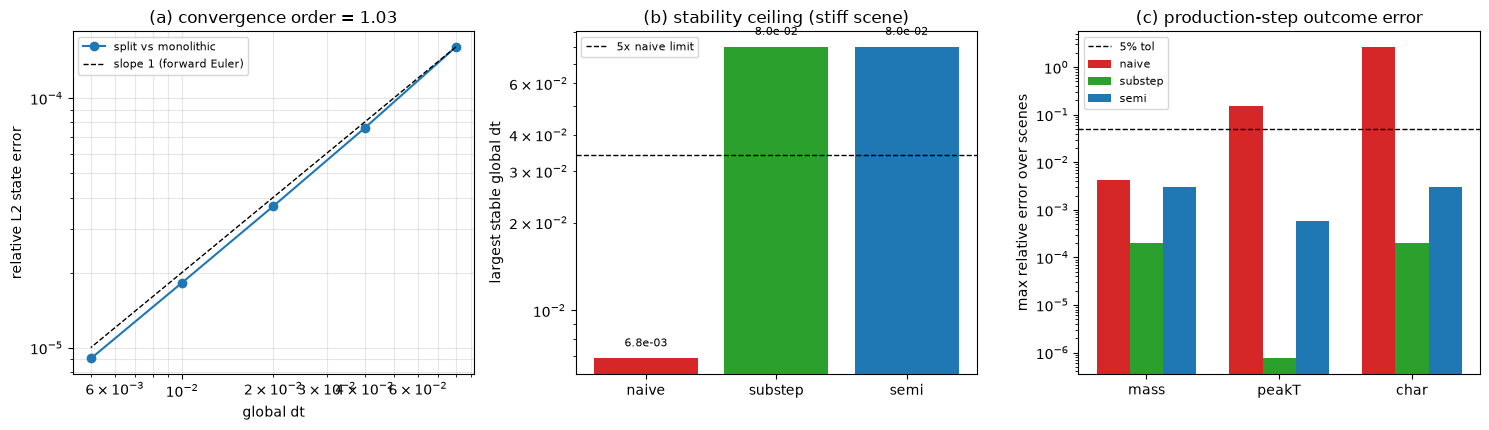

In [6]:
"""(5) Figures: (a) convergence-order fit; (b) stability ceilings; (c) production outcome errors."""
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# (a) convergence order — log-log error vs dt with the fitted order-1 line
ax[0].loglog(A_dts, A_errs, "o-", color="tab:blue", label="split vs monolithic")
ref_line = np.array(A_errs[0]) * (np.array(A_dts) / A_dts[0]) ** 1.0
ax[0].loglog(A_dts, ref_line, "k--", lw=1, label="slope 1 (forward Euler)")
ax[0].set_xlabel("global dt"); ax[0].set_ylabel("relative L2 state error")
ax[0].set_title(f"(a) convergence order = {A_order:.2f}")
ax[0].legend(fontsize=8); ax[0].grid(True, which="both", alpha=0.3)

# (b) stability ceilings — largest stable dt per method, with the naive baseline + 5x line
methods = ["naive", "substep", "semi"]
vals = [E_stable[m] for m in methods]
colors = ["tab:red", "tab:green", "tab:blue"]
ax[1].bar(methods, vals, color=colors)
ax[1].axhline(E_stable["naive"] * STEP_RATIO, ls="--", color="k", lw=1,
              label=f"{STEP_RATIO:.0f}x naive limit")
ax[1].set_yscale("log"); ax[1].set_ylabel("largest stable global dt")
ax[1].set_title("(b) stability ceiling (stiff scene)"); ax[1].legend(fontsize=8)
for i, v in enumerate(vals): ax[1].text(i, v * 1.1, f"{v:.1e}", ha="center", fontsize=8)

# (c) production-step outcome error per method (max over scenes), vs the 5% line
keys = ["mass", "peakT", "char"]
x = np.arange(len(keys)); w = 0.25
for j, m in enumerate(methods):
    h = [max(prod_rows[s][m][0][k] for s in PROD) for k in keys]
    ax[2].bar(x + (j - 1) * w, h, w, color=colors[j], label=m)
ax[2].axhline(TOL, ls="--", color="k", lw=1, label=f"{TOL:.0%} tol")
ax[2].set_yscale("log"); ax[2].set_xticks(x); ax[2].set_xticklabels(keys)
ax[2].set_ylabel("max relative error over scenes")
ax[2].set_title("(c) production-step outcome error"); ax[2].legend(fontsize=8)

fig.tight_layout()
outdir = REPO / "verification_notebooks" / "phase1" / "results"
outdir.mkdir(parents=True, exist_ok=True)
fig.savefig(outdir / "V1_2_split_stability.png", dpi=110)
print(f"saved figure -> {outdir / 'V1_2_split_stability.png'}")
plt.show()


In [7]:
"""(6) Frozen verdict."""
def verdict(name, passed, detail, outcome):
    print(f"  [{'OK ' if passed else 'XX '}] {name:34s} {'PASS' if passed else f'FAIL -> {outcome}'}")
    print(f"        {detail}")

print("=" * 80)
print("V1.2 — OPERATOR-SPLITTING STABILITY FOR STIFF CYCLIC COUPLING — VERDICT")
print("=" * 80)
verdict("A. convergence order ~ 1", A_PASS,
        f"explicit split -> monolithic at order {A_order:.2f} in [{ORDER_LO},{ORDER_HI}] "
        f"(forward Euler; no commutator error)", "REDESIGN (inconsistent split)")
verdict("B. naive corrupted (necessity)", B_PASS,
        "naive single-step exceeds 5% on >=1 integrated outcome at production dt "
        "(clamp corruption) -> the stiff loop needs a fix", "—")
verdict("C. sub-stepping fix (CONSTRAIN)", C_PASS,
        "rate-driven sub-stepping holds <5% on mass/peakT/char at the production dt", "CONSTRAIN")
verdict("D. semi-implicit fix (REDESIGN)", D_PASS,
        "semi-implicit split holds <5% in a single step/global -> lifts the sub-step constraint",
        "REDESIGN insufficient")
verdict("E. stable step >= 5x naive", E_PASS,
        f"substep {E_ratio_sub:.0f}x, semi {E_ratio_sem:.0f}x the naive explicit limit", "CONSTRAIN")

ALL_PASS = A_PASS and B_PASS and C_PASS and D_PASS and E_PASS
print("=" * 80)
if ALL_PASS:
    print("  V1.2 OVERALL: PASS — the additive split is consistent (order 1) and the stiff")
    print("                char<->conduction<->pyrolysis loop is stable at production steps via")
    print("                the rate-refinement local timestep; the semi-implicit split is the")
    print("                validated REDESIGN alternative. Decision #12 holds for stiff coupling.")
    print("  STANDING CONSTRAINT: the plain explicit split requires sub-stepping (or semi-implicit")
    print("                treatment) on stiff reaction loops — wired via the refinement rate term.")
else:
    print("  V1.2 OVERALL: FAIL — see outcome class above.")
print("=" * 80)
assert ALL_PASS, "V1.2 did not pass — see verdict above."


V1.2 — OPERATOR-SPLITTING STABILITY FOR STIFF CYCLIC COUPLING — VERDICT
  [OK ] A. convergence order ~ 1           PASS
        explicit split -> monolithic at order 1.03 in [0.9,1.3] (forward Euler; no commutator error)
  [OK ] B. naive corrupted (necessity)     PASS
        naive single-step exceeds 5% on >=1 integrated outcome at production dt (clamp corruption) -> the stiff loop needs a fix
  [OK ] C. sub-stepping fix (CONSTRAIN)    PASS
        rate-driven sub-stepping holds <5% on mass/peakT/char at the production dt
  [OK ] D. semi-implicit fix (REDESIGN)    PASS
        semi-implicit split holds <5% in a single step/global -> lifts the sub-step constraint
  [OK ] E. stable step >= 5x naive         PASS
        substep 12x, semi 12x the naive explicit limit
  V1.2 OVERALL: PASS — the additive split is consistent (order 1) and the stiff
                char<->conduction<->pyrolysis loop is stable at production steps via
                the rate-refinement local timestep; the semi